# GRU with crypto sentiment scores

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, Dense
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Define global environment variables

# Train-val-test split (70% training, 15% validation, 15% test)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert TRAIN_RATIO + VAL_RATIO + TEST_RATIO == 1.0, "Splits must sum to 1.0"

# Model hyperparameters
WINDOW_SIZE = 60  # Assuming minute-level data (1 hour)
NUM_NEURONS = 128
DROPOUT_RATE = 0.3
PATIENCE = 10
EPOCHS = 100
BATCH_SIZE = 256

## Data analysis

In [3]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/3.0/Bitcoin_data_full.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [4]:
data

,open,high,low,close,Volume BTC,Volume USD,weighted_sentiment_score
date,,,,,,,
2021-02-05 10:53:00,37446.89,37447.13,37415.68,37430.00,2.000066,74862.470380,0.333760
2021-02-05 10:54:00,37461.03,37463.49,37430.96,37430.96,2.878405,107741.474771,0.000000
2021-02-05 10:55:00,37440.64,37476.73,37440.64,37473.12,1.085219,40666.531696,0.591740
2021-02-05 10:56:00,37482.24,37488.05,37456.35,37488.05,0.444753,16672.908456,0.591740
2021-02-05 10:57:00,37497.71,37499.73,37474.14,37478.90,0.594074,22265.252407,0.591740
...,...,...,...,...,...,...,...
2021-08-21 12:55:00,49198.33,49269.22,49177.51,49256.00,2.579924,127076.760187,0.330864
2021-08-21 12:56:00,49269.22,49325.51,49269.22,49324.00,0.279014,13762.107745,0.345120
2021-08-21 12:57:00,49338.97,49359.00,49263.11,49289.18,7.748776,381930.796807,0.183834


In [5]:
data.describe()

,open,high,low,close,Volume BTC,Volume USD,weighted_sentiment_score
count,283807.000000,283807.000000,283807.000000,283807.000000,283807.000000,2.838070e+05,283807.000000
mean,45840.248201,45871.654716,45808.670409,45840.697127,3.511252,1.621085e+05,0.232904
std,9602.219575,9606.117015,9598.321639,9602.470985,7.550653,3.460727e+05,0.227239
min,28900.300000,28920.000000,28600.000000,28839.680000,0.000000,0.000000e+00,-0.992598
25%,36657.800000,36686.585000,36625.315000,36655.905000,0.450432,1.969445e+04,0.000000
50%,46384.680000,46416.150000,46352.400000,46383.780000,1.394468,6.292736e+04,0.269723
75%,55381.985000,55422.565000,55340.925000,55383.095000,3.618060,1.672082e+05,0.392483
max,64842.860000,64895.220000,64731.250000,64859.300000,378.472889,1.378306e+07,0.936924


In [6]:
# The number of missing values 
data.isna().sum()

open                        0
high                        0
low                         0
close                       0
Volume BTC                  0
Volume USD                  0
weighted_sentiment_score    0
dtype: int64

## Data processing

In [7]:
# Train-val-test split 
train_ratio = TRAIN_RATIO
val_ratio = VAL_RATIO
test_ratio = TEST_RATIO

# Compute split indices
train_index = int(len(data) * train_ratio)
val_index = train_index + int(len(data) * val_ratio)

# Perform the splits
train_data = data.iloc[:train_index]                    
val_data = data.iloc[train_index:val_index]             
test_data = data.iloc[val_index:]                      

# Print the shapes to confirm
print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (198664, 7)
Validation shape: (42571, 7)
Test shape: (42572, 7)


In [8]:
# Ensure WINDOW_SIZE does not exceed dataset length
assert WINDOW_SIZE < len(train_data), "WINDOW_SIZE is too large for the dataset size!"

In [9]:
print("Train start:", train_data.index[0], "end:", train_data.index[-1])
print("Val start:", val_data.index[0], "end:", val_data.index[-1])
print("Test start:", test_data.index[0], "end:", test_data.index[-1])

Train start: 2021-02-05 10:53:00 end: 2021-06-23 09:56:00
Val start: 2021-06-23 09:57:00 end: 2021-07-22 23:27:00
Test start: 2021-07-22 23:28:00 end: 2021-08-21 12:59:00


In [10]:
# Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(train_data) # Fit only on training data

# Transform train, validation, and test data using the fitted scaler
train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)  

In [11]:
# Function to create sequences for time series forecasting
def create_sequences(data_array, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])
        y.append(data_array[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

In [12]:
# Define window size and target column
window_size = WINDOW_SIZE 
target_col = 'close'
target_col_idx = data.columns.get_loc(target_col)

# Create sequences for training, validation and test sets
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)
X_test, y_test = create_sequences(test_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(198604, 60, 7) (198604,)
(42511, 60, 7) (42511,)
(42512, 60, 7) (42512,)


## Model training (GRU)

In [13]:
# Define GRU model
gru_model = Sequential([
    GRU(NUM_NEURONS, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(DROPOUT_RATE),
    Dense(1) # Predicting the close price
])
gru_model.compile(optimizer=Adam(), loss='mean_squared_error')
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        52,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,737 (206.00 KB)

 Trainable params: 52,737 (206.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

# Train the model
history = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - loss: 0.0150 - val_loss: 2.2692e-05
Epoch 2/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - loss: 0.0013 - val_loss: 7.8135e-06
Epoch 3/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - loss: 0.0010 - val_loss: 1.2416e-05
Epoch 4/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - loss: 7.7575e-04 - val_loss: 6.3473e-06
Epoch 5/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - loss: 5.6512e-04 - val_loss: 1.1479e-05
Epoch 6/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - loss: 3.9881e-04 - val_loss: 3.1472e-06
Epoch 7/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - loss: 2.9949e-04 - val_loss: 2.5124e-06
Epoch 8/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - loss: 2.5222e-04 - val_loss: 1.7917e-06
Epoch 9/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - loss: 2.3136e-04 - val_loss: 9.1662e-06
Epoch 10/100
776/776 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - loss: 2.2576e-04 - val_loss: 8.2274e-05
Epoch 11/100
776/776 ━━━━━━━━━━━━━━━━━━━━

In [15]:
# Training and validation loss
history.history.keys()

dict_keys(['loss', 'val_loss'])

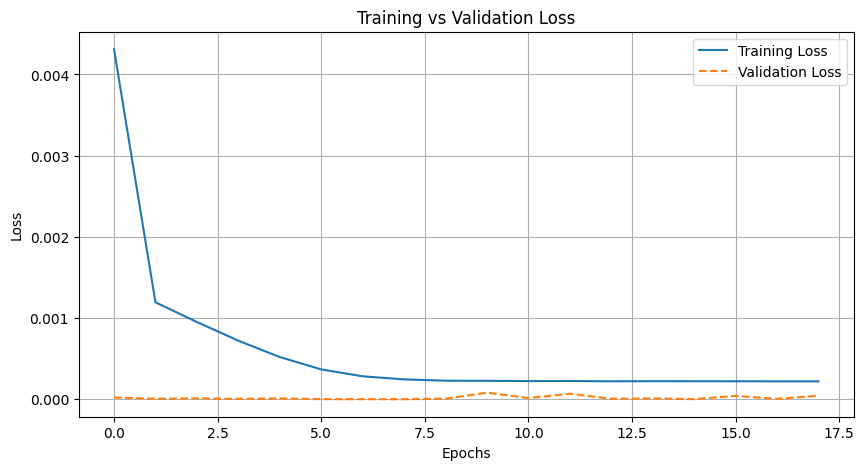

In [16]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation 

In [17]:
# Crate an inverse function
def inverse_transform_predictions(predicted_scaled, y_actual_scaled, scaler, train_data, target_col_idx):
    """
    Inverse transforms the scaled predictions and actual values back to the original scale.

    Parameters:
    - predicted_scaled: Model predictions in scaled form (shape: (n_samples, 1)).
    - y_actual_scaled: Actual target values in scaled form (shape: (n_samples,)).
    - scaler: The MinMaxScaler fitted on the training data.
    - train_data: The original training dataset (used to get the number of features for inverse transform).
    - target_col_idx: The index of the target column in the dataset.

    Returns:
    - predicted_inverse: Predictions in the original scale.
    - y_actual_inverse: Actual values in the original scale.
    """

    # Create full arrays with the same shape as train_data for inverse transformation
    predicted_full = np.zeros((predicted_scaled.shape[0], train_data.shape[1]))
    y_actual_full = np.zeros((y_actual_scaled.shape[0], train_data.shape[1]))

    # Fill only the target column ('close' price)
    predicted_full[:, target_col_idx] = predicted_scaled[:, 0]  # Ensure correct shape
    y_actual_full[:, target_col_idx] = y_actual_scaled  # y_actual is already 1D

    # Apply inverse transform
    predicted_inverse = scaler.inverse_transform(predicted_full)[:, target_col_idx]
    y_actual_inverse = scaler.inverse_transform(y_actual_full)[:, target_col_idx]

    return predicted_inverse, y_actual_inverse

### Training set evaluation 

In [18]:
# Get inverse transformed predictions and actual values
predicted_train_inverse, y_train_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_train),
    y_actual_scaled=y_train,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

6207/6207 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step


In [19]:
# Compute error metrics for the training set
mae_train = mean_absolute_error(y_train_inverse, predicted_train_inverse)
rmse_train = sqrt(mean_squared_error(y_train_inverse, predicted_train_inverse))
mape_train = np.mean(np.abs((y_train_inverse - predicted_train_inverse) / y_train_inverse)) * 100  

print(f"Train MAE: {mae_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAPE: {mape_train:.2f}%")

Train MAE: 60.5119
Train RMSE: 89.4503
Train MAPE: 0.13%


### Validation set evaluation 

In [20]:
# Get inverse transformed predictions and actual values
predicted_val_inverse, y_val_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_val),
    y_actual_scaled=y_val,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step


In [21]:
# Compute error metrics for the val set
mae_val = mean_absolute_error(y_val_inverse, predicted_val_inverse)
rmse_val = sqrt(mean_squared_error(y_val_inverse, predicted_val_inverse))
mape_val = np.mean(np.abs((y_val_inverse - predicted_val_inverse) / y_val_inverse)) * 100  

print(f"Validation MAE: {mae_val:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")
print(f"Validation MAPE: {mape_val:.2f}%")

Validation MAE: 33.8689
Validation RMSE: 48.2138
Validation MAPE: 0.10%


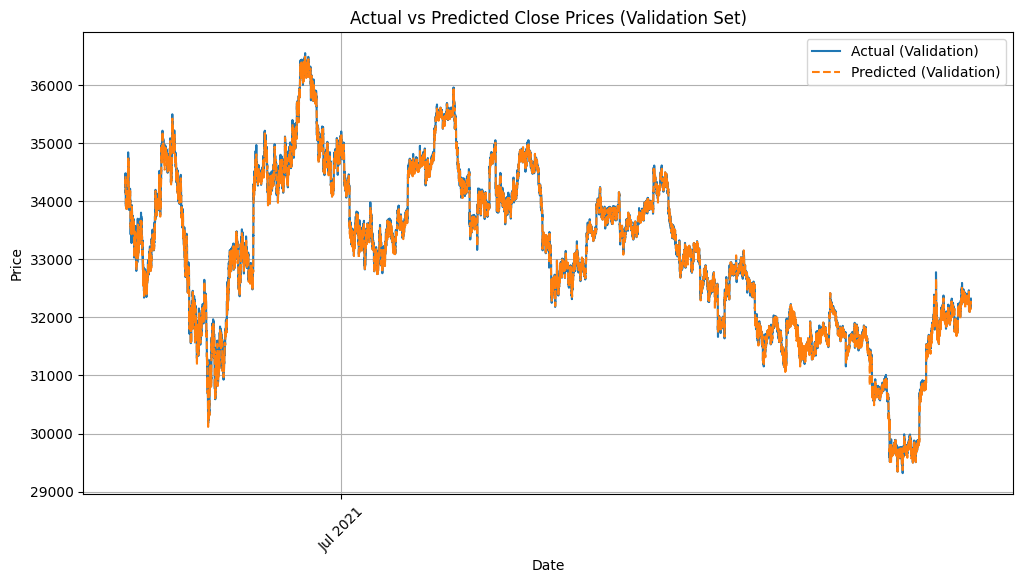

In [22]:
# Extract date index for plotting
date_index = val_data.index[window_size:]  # Align with sequence offset

# Plot actual vs predicted close prices for validation set
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='Predicted (Validation)', linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Benchmark against a Naïve Forecast

In [23]:
val_data.head()

,open,high,low,close,Volume BTC,Volume USD,weighted_sentiment_score
date,,,,,,,
2021-06-23 09:57:00,33946.05,33980.92,33924.13,33924.13,2.623599,89003.304384,0.202943
2021-06-23 09:58:00,33947.28,33967.98,33947.28,33951.51,0.248761,8445.797319,0.303304
2021-06-23 09:59:00,33965.16,33965.16,33931.12,33931.12,0.028782,976.598370,-0.043894
2021-06-23 10:00:00,33956.00,33994.35,33955.99,33975.11,0.456998,15526.549166,0.179937
2021-06-23 10:01:00,33982.68,34021.81,33982.68,34021.81,0.522496,17776.273927,0.145944


In [24]:
actual_val = val_data['close']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_val.iloc[window_size - 1:-1].values
actual_val_values = actual_val.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_val_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_val_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_val_values - naive_predictions) / actual_val_values)) * 100

print(f"Validation Naive MAE: {mae_naive:.4f}")
print(f"Validation Naive RMSE: {rmse_naive:.4f}")
print(f"Validation Naive MAPE: {mape_naive:.2f}%")

Validation Naive MAE: 23.8619
Validation Naive RMSE: 34.8753
Validation Naive MAPE: 0.07%


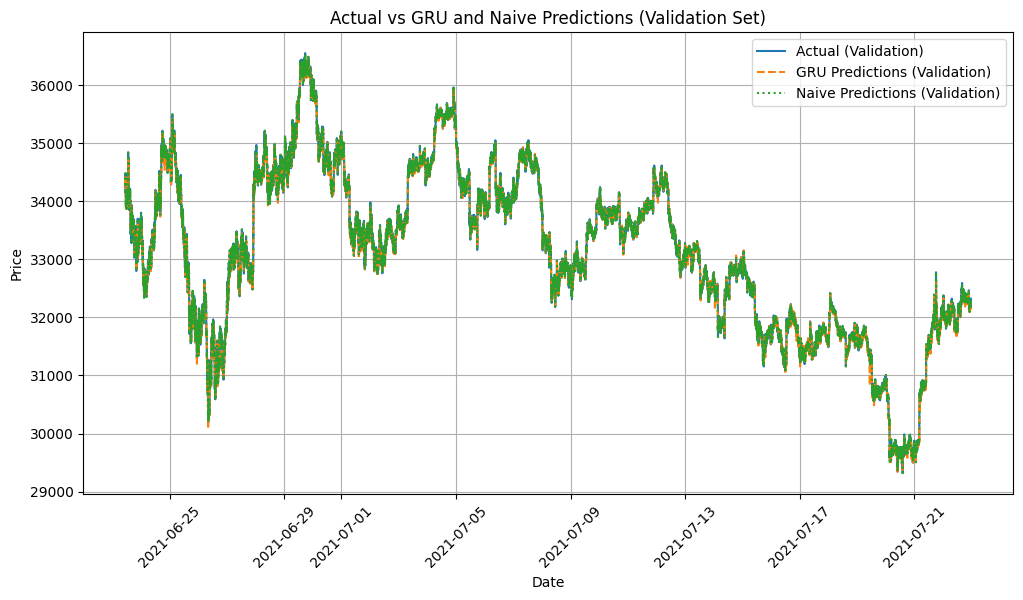

In [25]:
# Prepare a date index for plotting (adjusting for the sequence offset)
date_index = val_data.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='GRU Predictions (Validation)', linestyle='dashed')
plt.plot(date_index, naive_predictions, label='Naive Predictions (Validation)', linestyle='dotted')
plt.title('Actual vs GRU and Naive Predictions (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()